#### Exploring and visualizing data

In [40]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [65]:
## load an .npy file (a structure) in the "Data" folder
data_dir = '/Users/kshiti/ML4MaterialsScience-course/data'
str_list=os.listdir(data_dir) #returns a list containing the names of the entries in the directory

len(str_list) 

362

In [66]:
data= np.load(data_dir + '/' + str_list[1])
print('type of data',type(data))
print('data dimension',data.ndim)    #File contains three dimensional array
print('shape of data',data.shape )   # Axis are 100 units in each of the three dimensions

type of data <class 'numpy.ndarray'>
data dimension 3
shape of data (100, 100, 100)


#### Visualising microstructure

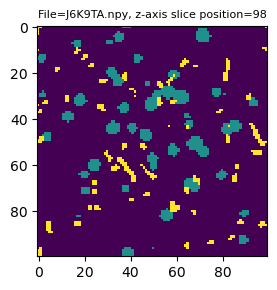

In [67]:
zSlicePosition = 98      # position of a microstructure slice along the z-axis for visualisation: choose from (0-99) due to 100x100x100 data
data = np.load(data_dir+'/'+str_list[42]) #Visualising image 42 on the data list
dataSlice=data[:,:,zSlicePosition]    # slice at the the x3 dimension and retain x1,x2 untouched

plt.figure(figsize = (4,3))
plt.imshow(dataSlice,interpolation='nearest')
plt.title(f'File={str_list[42]}, z-axis slice position={zSlicePosition}', fontsize=8)
plt.show()

In [68]:
print(dataSlice)
print(np.shape(dataSlice))
print(np.unique(dataSlice))

[[2 2 0 ... 0 0 2]
 [2 0 0 ... 0 0 0]
 [2 0 0 ... 0 0 0]
 ...
 [2 2 0 ... 0 0 0]
 [2 2 0 ... 0 0 0]
 [2 2 0 ... 0 0 0]]
(100, 100)
[0 1 2]


The above parameter "dataSlice" is a 100x100 array, with each element taking one out of the unique values 0, 1, or 2. 

Each point of the array corresponds to a spatial coordinate of the synthetic material structure. The values of each array element (0, 1, or 2) represent the constituent compound occupying that spatial coordinate, such that:

- 0 -> Silica (SiO2)
- 1 -> ß-SiC
- 2 -> Segregated Carbon

In the next section, the 2D volume fraction of each constitutent for a given slice is calculated for the first four files in the dataset.

#### Calculating Volume Fractions of Different Phases

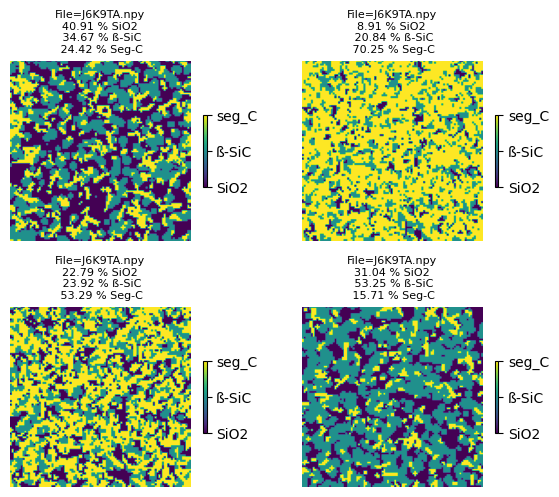

In [69]:
#Calculation of phase volume fraction in 2D slices
plt.rcParams["figure.figsize"] = [6, 10]      # width and height of the figure
plt.rcParams["figure.autolayout"] = True

zSlicePosition = 10      # position of a microstructure slice along the z-axis for visualisation

for i in range(len(str_list[:4])):  # first 4 files
    n0,n1,n2 = 0,0,0                # reset iterative variable for volume fraction of each constituent
    data = np.load(data_dir+'/'+str_list[i])
    dataSlice=data[:,:,zSlicePosition]    # slice at the the x3 dimension and leave x1,x2 untouched


    plt.subplot(4,2,i+1)
    plt.title("Volume fractions of selected compositions")
    plt.imshow(dataSlice)               # Save the plotted images in memory
    plt.axis('off')
    #This code iterates through every pixel, counts how many pixels have values 0, 1, or 2, and stores the totals in n0, n1, and n2.
    for pixel in np.nditer(dataSlice):   # nditer(): multi-D iterator to iterate over arrays
        if pixel == 1:
            n1 += 1
        elif pixel == 2:
            n2 += 1
        elif pixel == 0:
            n0 += 1
    TotalPixels = dataSlice.size
    plt.title(str_list[i]+" @z="+str(zSlicePosition),fontsize=16)
    plt.title(f'File={str_list[42]}\n{str(n0*100/TotalPixels)} % SiO2\n {str(n1*100/TotalPixels)} % ß-SiC\n {str(n2*100/TotalPixels)} % Seg-C',fontsize=8)

    cbar = plt.colorbar(ticks=[0, 1, 2],shrink=0.4)  

    cbar.set_ticklabels(['SiO2', 'ß-SiC', 'seg_C'])  # Setting corresponding tick labels


plt.show()  # show sketch and plotted images


#### Calculating 3D Volume Fractions for each sample



In [70]:
VolFrac = []       # Volume Fractions as a list (Filename,0,1,2)
str_list = [f for f in os.listdir(data_dir) if f.endswith('.npy')] #As we have an .md readme file, it is giving errors, so we adapt the code to include only .npy files in list
Fin = len(str_list) #total number of files
i=0
for File in str_list:
    #print(File)
    i += 1
    n0,n1,n2 = 0,0,0  #reset the voxel count for each file
    file_path = os.path.join(data_dir, File) #builds the full file path
    #print(file_path)
    data = np.load(file_path, allow_pickle=True) #Loading the 3d data array from each file
    n1 = np.sum(data == 1)     #takes all the spatial coordinates/voxels where the value is 1 i.e. all the silica in the 3D array
    n2 = np.sum(data == 2)
    n0 = np.sum(data == 0)
    TotalVoxels = data.size   #total number of voxels in the 3d array to obtain volume fraction of each element
    VolFrac.append([File,n0/TotalVoxels,n1/TotalVoxels,n2/TotalVoxels])    #stores the fraction of each material.
    print("({i}/{Fin}) {File} (".format(i=i,Fin=Fin,File=File) + "SiO2: " +str(n0*100/TotalVoxels)+ "% / ß-SiC: " +str(n1*100/TotalVoxels)+ "% / segregated Carbon: " + str(n2*100/TotalVoxels)+ "%)")

(1/360) M9YE9G.npy (SiO2: 40.0004% / ß-SiC: 36.2936% / segregated Carbon: 23.706%)
(2/360) TIZM8P.npy (SiO2: 10.0% / ß-SiC: 21.5002% / segregated Carbon: 68.4998%)
(3/360) 54XXZC.npy (SiO2: 24.9998% / ß-SiC: 24.8901% / segregated Carbon: 50.1101%)
(4/360) 03V8QP.npy (SiO2: 29.9975% / ß-SiC: 54.5218% / segregated Carbon: 15.4807%)
(5/360) 1RC67U.npy (SiO2: 74.9996% / ß-SiC: 22.1898% / segregated Carbon: 2.8106%)
(6/360) UAMQ72.npy (SiO2: 34.9999% / ß-SiC: 3.5678% / segregated Carbon: 61.4323%)
(7/360) F7J1WZ.npy (SiO2: 15.0003% / ß-SiC: 28.1609% / segregated Carbon: 56.8388%)
(8/360) RG748E.npy (SiO2: 14.9997% / ß-SiC: 1.1572% / segregated Carbon: 83.8431%)
(9/360) O49B1L.npy (SiO2: 60.0046% / ß-SiC: 21.5517% / segregated Carbon: 18.4437%)
(10/360) 1XXRLM.npy (SiO2: 4.9999% / ß-SiC: 22.6322% / segregated Carbon: 72.3679%)
(11/360) DRJ4CT.npy (SiO2: 50.0% / ß-SiC: 3.4664% / segregated Carbon: 46.5336%)
(12/360) F93XZF.npy (SiO2: 19.9999% / ß-SiC: 21.0528% / segregated Carbon: 58.9473%)
(

In [ ]:
# #Debugging step - to visualise all files in the list
# str_list = os.listdir(data_dir) 
# str_list = [f for f in os.listdir(data_dir) if f.endswith('.npy')]

# print(f"Total files: {len(str_list)}")
# for f in str_list:
#     print(f)

# # See all unique file extensions in the folder
# extensions = set(os.path.splitext(f)[1] for f in str_list)
# print("File types found:", extensions)

# # See only non-.npy files (the problem ones)
# non_npy = [f for f in str_list if not f.endswith('.npy')]
# print("Non-npy files:", non_npy)

# #the readme.md file was causing the error as it is not a data file. As the data is described in the notebook, this file can be removed.

In [ ]:
# making a pandas dataframe (structured table) from the VolFrac list
pd_VolFrac =pd.DataFrame(VolFrac,columns=["File Names","SiO2","ß-SiC","seg-Carbon"])
pd_VolFrac.head(10) #.head() by default gives the first 5 rows; .head(10) gives first 10 rows on the table

# The main reason to convert to a DataFrame here is that it makes the data much easier to work with going forward 
# Sorting, filtering, plotting, saving to CSV, etc. are all straightforward with Pandas.

,File Names,SiO2,ß-SiC,seg-Carbon
0,M9YE9G.npy,0.400004,0.362936,0.237060
1,TIZM8P.npy,0.100000,0.215002,0.684998
2,54XXZC.npy,0.249998,0.248901,0.501101
3,03V8QP.npy,0.299975,0.545218,0.154807
4,1RC67U.npy,0.749996,0.221898,0.028106
5,UAMQ72.npy,0.349999,0.035678,0.614323
6,F7J1WZ.npy,0.150003,0.281609,0.568388
7,RG748E.npy,0.149997,0.011572,0.838431
8,O49B1L.npy,0.600046,0.215517,0.184437
9,1XXRLM.npy,0.049999,0.226322,0.723679


#### Merging Volume fraction data with Thermal conductivity data

In [76]:
file_path = os.path.join(data_dir, "npy_filename_with_thermal_conductivity_group1.csv") #to select the .csv file containing thermal conductivity values for each sample
df = pd.read_csv(file_path,usecols=[1,2]) #loads only columns with index 1 and 2, skipping the rest
df.head() 

,File Names,Effective Thermal Cond
0,M6LJOC.npy,2.46
1,YV6EHV.npy,2.47
2,UD6BZ3.npy,2.49
3,E67POQ.npy,2.50
4,WKQU5T.npy,2.52


In [ ]:
# combining the two dataframes - VolFrac and thermalCond. data
Merged = pd.merge(df,pd_VolFrac) #merges the two data frames by merging the common column - 'filename' - to get both data frames side to side
Merged.rename(columns = {'Effective Thermal Cond':'Therm Cond.'}, inplace = True) #rename longer column name "Effective thermal conductivity" to "Therm Cond."
Merged.head()


,File Names,Therm Cond.,SiO2,ß-SiC,seg-Carbon
0,M6LJOC.npy,2.46,0.050000,0.004768,0.945232
1,YV6EHV.npy,2.47,0.049999,0.010761,0.939240
2,UD6BZ3.npy,2.49,0.050000,0.018233,0.931767
3,E67POQ.npy,2.50,0.049998,0.027325,0.922677
4,WKQU5T.npy,2.52,0.049999,0.039157,0.910844


In [ ]:
file_path = os.path.join(data_dir, "VolumeFraction.csv") #defining filepath to create new CSV file with merged data frame
Merged.to_csv(file_path)       # Create .csv file

#### Primary Data Exploration

We use Seaborn (a Python data visualization library built on Matplotlib) to visualize correlations between the effective thermal conductivity and the material constituents.
The 'Pairplot' and 'HeatMap' functions are used.

#### Pairplot:



/Users/suhas/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/suhas/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/suhas/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/suhas/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Conver

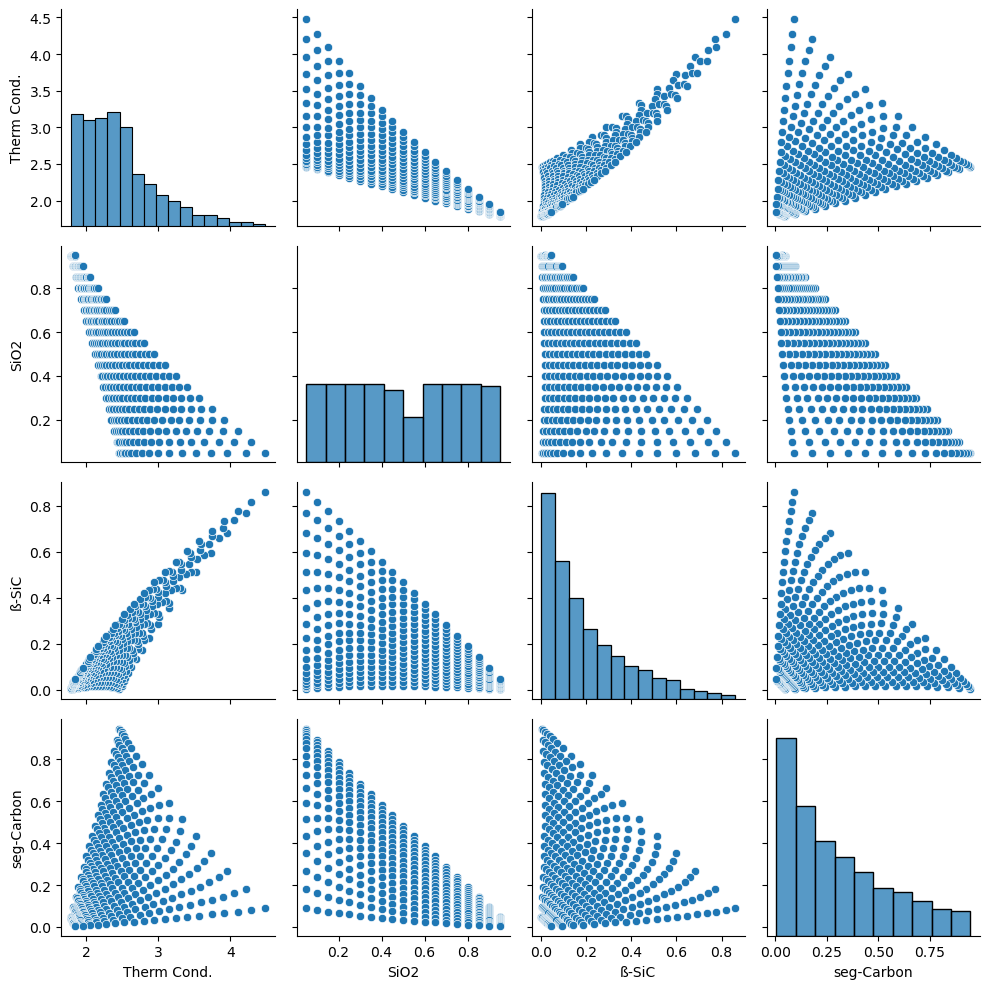

In [82]:
import seaborn as sns
sns.pairplot(Merged)

The plot is a 4×4 matrix of subplots for four variables: Therm Cond., SiO2, ß-SiC, and seg-Carbon, such that:
- Diagonal = histogram of each individual variable alone (e.g. how the values of seg-Carbon are distributed across the dataset)
- Off-diagonal = scatter plot of the row variable (y-axis) vs column variable (x-axis) (There are pairs of plots that are mirror images of each other (with the axes flipped).)

##### How to interpret this:
##### **Diagonals - Histograms:**
- **Therm Conductivity :** Most samples cluster between 2.0–3.5. Moving toward higher thermal conductivity values (above 3.5 to 4.5), the number of samples drops off sharply. This tells us that achieving high thermal conductivity is relatively rare or represents a boundary condition in the dataset.
- **SiO2 :** Fairly flat/uniform — compositions were likely deliberately spread across a range. Probably the dataset was generated via a systematic grid search or a controlled experimental design, sampling equal amounts of data at almost every composition level.
- **ß-SiC :** Heavily skewed — most samples have low ß-SiC, fewer have high amounts
- **seg-Carbon :** Very skewed — the vast majority of samples have very little segregated carbon
Because this is a multi-component mixture (where SiO2+β-SiC+seg-Carbon≈1.0), we cannot have high amounts of everything at once.
The uniform distribution of SiO2 combined with the heavily skewed distributions of β-SiC and seg-Carbon indicates how the experimental space was sampled: SiO2 was likely treated as the primary baseline matrix variable, while the remaining space was divided among the other components.


##### **Off-diagonals - Scatter Plots:**
Almost all scatter plots form strict right triangles or bounded wedges rather than random clouds of data points. This happens because the compositional variables (SiO2, β-SiC, and seg-Carbon) represent fractions or percentages that add up to 1. For e.g. the plot for β-SiC vs. SiO2 (row 2, column 3, or row 3, column 2) forms a perfect diagonal boundary line running from the top-left to the bottom-right, indicating the strict physical constraint: SiO2 + β-SiC ≤ (an upper bound). As one component increases, the maximum possible amount of the other component must decrease.
​

The top row (or bottom-left column) shows how the material's composition affects its Thermal Conductivity:
- **SiO2 vs. Thermal Conductivity Pattern:** A downward-sloping triangle.
Interpretation: As the fraction of SiO2 increases, the maximum possible Thermal Conductivity drops sharply. When SiO2 is near its maximum (~0.9), the thermal conductivity is locked at its lowest values (~1.8). This suggests SiO2 acts as a thermal insulator in this material system.
- **β-SiC vs. Thermal Conductivity Pattern:** A distinct upward, curving banana/wedge shape.
Interpretation: There is a strong positive correlation. As the fraction of β-SiC increases, the Thermal Conductivity increases significantly, reaching its highest values (~4.5) when β-SiC is at its maximum (~0.85). β-SiC is clearly the primary driver of high thermal conductivity in this mix.
- **seg-Carbon vs. Thermal Conductivity Pattern:** An asymmetric fan/wedge shape peaking at low-to-mid values.
Interpretation: The highest thermal conductivities are achieved when seg-Carbon is kept quite low (around 0.0 to 0.1). As seg-Carbon increases past 0.2, the maximum achievable thermal conductivity steadily declines.
**Summary**
If the goal is to maximize Thermal Conductivity, we would need:
- high β-SiC content.
- low SiO2
- low seg-Carbon content.

(The discrete "lines" of dots within the triangles also suggest that this data came from a systematic grid search or a controlled simulation where composition values were stepped by specific, uniform intervals.)

#### Heatmap:

<Axes: >

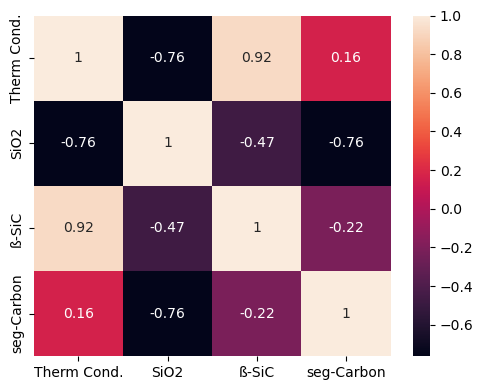

In [85]:
plt.subplots(figsize=(5,4))
sns.heatmap(Merged.select_dtypes(include='number').corr(), annot=True)

##### How to interpret this:

The heatmap shows Pearson correlation coefficients between all four variables. The values range from −1.0 (perfect negative linear relationship) to +1.0 (perfect positive linear relationship), with 0 meaning no linear relationship at all. The diagonal is always 1 since every variable is perfectly correlated with itself.

The top row (or the first column) clearly shows which components dictate the material's thermal properties:
- **β-SiC vs. Therm Cond. (r=0.92):** This is a very strong, positive correlation. A value of 0.92 tells us that β-SiC is the absolute primary driver of high thermal conductivity in this system. For a high thermally conductive material, maximizing this component is the best way.
- **SiO2 vs. Therm Cond. (r=−0.76):** This is a strong, negative correlation. It confirms that SiO2 strongly degrades thermal conductivity, acting as an effective thermal insulator.
- **seg-Carbon vs. Therm Cond. (r=0.16):** This is a weak, slightly positive correlation. (It is weakly positive here when the pair-plot implied that it generally dragged thermal conductivity down at higher amounts. Pearson correlation looks for linear relationships across the whole dataset. Since the highest thermal conductivity values occur when seg-Carbon is slightly above zero (indicated by the asymmetric wedge or peak in the pair plot), a simple linear correlation coefficient struggles to capture the non-linear relationship.)

The negative correlation between the chemical constituents reflects the compositional constraint (SiO2+β-SiC+seg-Carbon≤1.0). 
In a closed mixture system, the components are inherently competitive. If more of one component is added, the total share of the other components is mathematically forced to reduce.